# Setup

In [1]:
# ติดตั้ง library เพิ่มเติม
%pip install plotly kaleido -q

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# ดาวน์โหลดฟอนต์ภาษาไทย (Sukhumvit-Medium)
!curl -L -o SukhumvitSet-Medium.ttf https://github.com/bluenex/baansuan_prannok/raw/master/fonts/sukhumvit-set/SukhumvitSet-Medium.ttf
#เพิ่มฟอนต์เข้าไปในระบบ
mpl.font_manager.fontManager.addfont('SukhumvitSet-Medium.ttf')
mpl.rc('font', family='SukhumvitSet-Medium', size=16)
sns.set_theme(style="whitegrid", font="SukhumvitSet-Medium")

# ตั้งค่า style
plt.rcParams['figure.dpi'] = 120

print('Setup Completed')

Note: you may need to restart the kernel to use updated packages.
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 84932  100 84932    0     0  88164      0 --:--:-- --:--:-- --:--:-- 88164
Setup Completed


In [2]:
# 1. Register the font file
font_path = 'SukhumvitSet-Medium.ttf'
mpl.font_manager.fontManager.addfont(font_path)

# 2. Find the actual internal name of the font
prop = mpl.font_manager.FontProperties(fname=font_path)
font_name = prop.get_name()
print(f"Detected Font Name: {font_name}")

# 3. Set the parameters using the detected name
plt.rcParams['font.family'] = font_name
sns.set_theme(style="whitegrid", font=font_name)

# Optional: Fix minus signs showing as boxes in Thai fonts
plt.rcParams['axes.unicode_minus'] = False 

print('Setup Completed with font:', font_name)

Detected Font Name: Sukhumvit Set
Setup Completed with font: Sukhumvit Set


# เตรียมข้อมูล

In [3]:
df_2025 = pd.read_csv('uploads1-9-20260312-160940321.csv', encoding='utf-8-sig')
df_2026 = pd.read_csv('uploads1-9-20260312-160940030.csv', encoding='utf-8-sig')

In [4]:
print('='*60)
print('2025')
print(f'{df_2025.shape[0]:} rows | column {df_2025.shape[1]} columns')
print(f'columns : {df_2025.columns.tolist()}')

print('='*60)
print('2026')
print(f'{df_2026.shape[0]:} rows | column {df_2026.shape[1]} columns')
print(f'columns : {df_2026.columns.tolist()}')

print('='*60)
print('2025 Example :')
display(df_2025.head(3))
display(df_2025.tail(3))

print('='*60)

print('2026 Example :')
display(df_2026.head(3))
display(df_2026.tail(3))


2025
69440 rows | column 8 columns
columns : ['รูปแบบการเดินทาง', 'วัตถุประสงค์', 'สาธารณะ/ส่วนบุคคล', 'หน่วยงาน', 'ยานพาหนะ/ท่า', 'วันที่', 'หน่วย', 'ปริมาณ']
2026
3010 rows | column 8 columns
columns : ['รูปแบบการเดินทาง', 'วัตถุประสงค์', 'สาธารณะ/ส่วนบุคคล', 'หน่วยงาน', 'ยานพาหนะ/ท่า', 'วันที่', 'หน่วย', 'ปริมาณ']
2025 Example :


,รูปแบบการเดินทาง,วัตถุประสงค์,สาธารณะ/ส่วนบุคคล,หน่วยงาน,ยานพาหนะ/ท่า,วันที่,หน่วย,ปริมาณ
0,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,บขส.,รถ บขส. และ รถร่วม,01/01/2025,คน,"127,551"
1,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,ขบ.,รถหมวด 3,01/01/2025,คน,"8,218"
2,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,ทล.,รถยนต์เฉพาะ 4 ล้อ (10 จุดสำรวจ),01/01/2025,คัน,"877,943"


,รูปแบบการเดินทาง,วัตถุประสงค์,สาธารณะ/ส่วนบุคคล,หน่วยงาน,ยานพาหนะ/ท่า,วันที่,หน่วย,ปริมาณ
69437,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69438,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69439,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


2026 Example :


,รูปแบบการเดินทาง,วัตถุประสงค์,สาธารณะ/ส่วนบุคคล,หน่วยงาน,ยานพาหนะ/ท่า,วันที่,หน่วย,ปริมาณ
0,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,บขส.,รถ บขส. และ รถร่วม,01/01/2026,คน,"112,325"
1,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,ขบ.,รถหมวด 3,01/01/2026,คน,0
2,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,ทล.,รถยนต์เฉพาะ 4 ล้อ (10 จุดสำรวจ),01/01/2026,คัน,"892,218"


,รูปแบบการเดินทาง,วัตถุประสงค์,สาธารณะ/ส่วนบุคคล,หน่วยงาน,ยานพาหนะ/ท่า,วันที่,หน่วย,ปริมาณ
3007,ทางอากาศ,การเดินทางระหว่างประเทศ,สาธารณะ,ทอท.,ท่าอากาศยานอื่น ๆ ของ ทอท. ขาออกประเทศ,11/03/2026,คน,"11,625"
3008,ทางอากาศ,การเดินทางระหว่างประเทศ,สาธารณะ,ทย.,ท่าอากาศยานภูมิภาค ขาเข้าประเทศ,11/03/2026,คน,998
3009,ทางอากาศ,การเดินทางระหว่างประเทศ,สาธารณะ,ทย.,ท่าอากาศยานภูมิภาค ขาออกประเทศ,11/03/2026,คน,"1,113"


In [5]:
df_2025.info()
print()
df_2026.info()

<class 'pandas.DataFrame'>
RangeIndex: 69440 entries, 0 to 69439
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   รูปแบบการเดินทาง   15696 non-null  str  
 1   วัตถุประสงค์       15696 non-null  str  
 2   สาธารณะ/ส่วนบุคคล  15696 non-null  str  
 3   หน่วยงาน           15696 non-null  str  
 4   ยานพาหนะ/ท่า       15696 non-null  str  
 5   วันที่             15696 non-null  str  
 6   หน่วย              15696 non-null  str  
 7   ปริมาณ             15388 non-null  str  
dtypes: str(8)
memory usage: 4.2 MB

<class 'pandas.DataFrame'>
RangeIndex: 3010 entries, 0 to 3009
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   รูปแบบการเดินทาง   3010 non-null   str  
 1   วัตถุประสงค์       3010 non-null   str  
 2   สาธารณะ/ส่วนบุคคล  3010 non-null   str  
 3   หน่วยงาน           3010 non-null   str  
 4   ยานพาหนะ/ท่า       3010 non-nu

In [6]:
# เนื่องจากข้อมูลปริมาณที่ได้มามีลูกน้ำคั่น จึงทำให้นำตัวเลขนำมาใช้ยาก จึงแปลงมาให้เป็นตัวเลข Float ไม่มีลูกน้ำคั่น
df_2025['ปริมาณ'] = df_2025['ปริมาณ'].astype(str).str.replace(',', '').astype(float)
df_2026['ปริมาณ'] = df_2026['ปริมาณ'].astype(str).str.replace(',', '').astype(float)

# และเปลี่ยนวันที่ให้เหมาะสมกับการนำไปวิเคราะห์กับ pandas 
df_2025['วันที่'] = pd.to_datetime(df_2025['วันที่'], format='%d/%m/%Y')
df_2026['วันที่'] = pd.to_datetime(df_2026['วันที่'], format='%d/%m/%Y')

In [7]:
# สถิติเบื้องต้น
for year, df in [('2025', df_2025), ('2026', df_2026)]:
    total = int(df['ปริมาณ'].sum())
    null_count = df.isnull().sum().sum()
    pass_count = df['ปริมาณ'].nunique()
    mode_count = df['รูปแบบการเดินทาง'].nunique()
    purpose_count = df['วัตถุประสงค์'].nunique()
    station_count = df['ยานพาหนะ/ท่า'].nunique()

    print(f'ปี {year}')
    print(f'   จำนวนปริมาณ : {pass_count} คน')
    print(f'   รูปแบบการเดินทาง : {mode_count} แบบ')
    print(f'   วัตถุประสงค์การเดินทาง : {purpose_count} แบบ')
    print(f'   ยานพาหนะ/ท่า : {station_count} แบบ')
    print(f'   ⚠️ ค่า Null : {null_count} ค่า')
    print()

ปี 2025
   จำนวนปริมาณ : 12162 คน
   รูปแบบการเดินทาง : 4 แบบ
   วัตถุประสงค์การเดินทาง : 3 แบบ
   ยานพาหนะ/ท่า : 43 แบบ
   ⚠️ ค่า Null : 430260 ค่า

ปี 2026
   จำนวนปริมาณ : 2528 คน
   รูปแบบการเดินทาง : 4 แบบ
   วัตถุประสงค์การเดินทาง : 3 แบบ
   ยานพาหนะ/ท่า : 43 แบบ
   ⚠️ ค่า Null : 136 ค่า



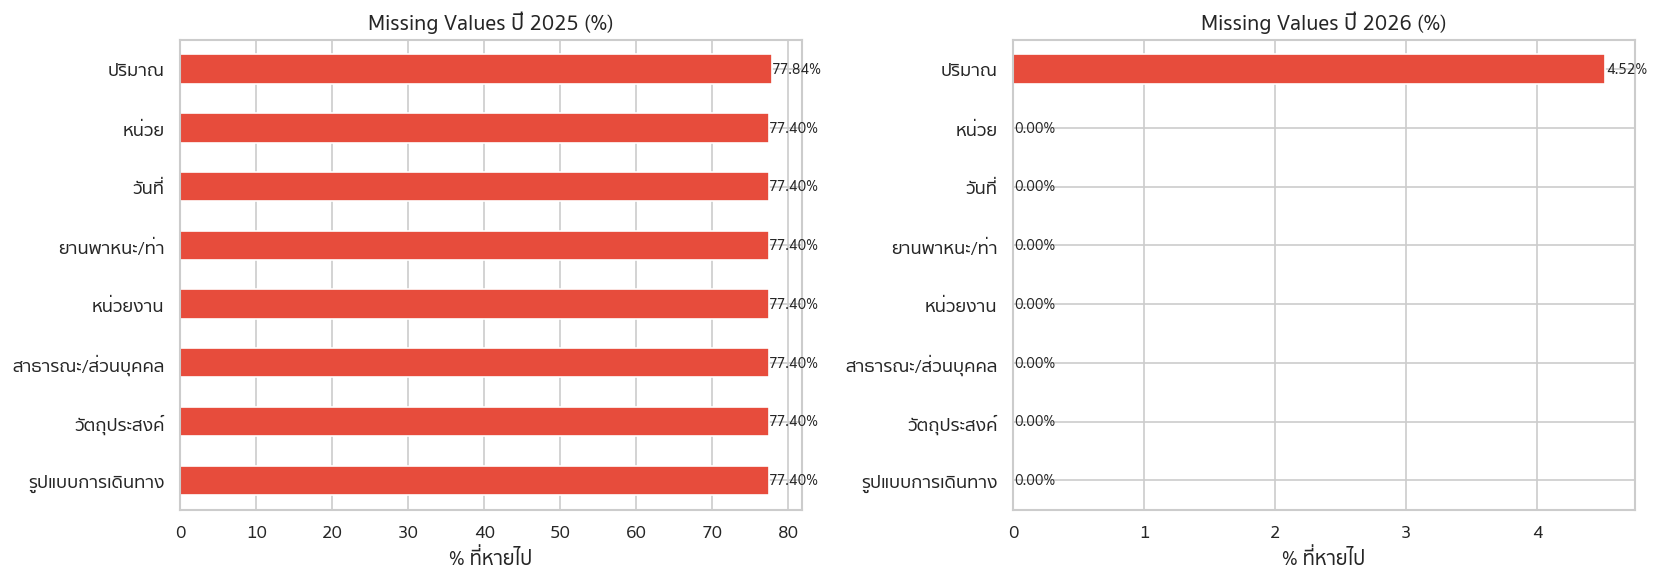

💡 แดง = มีค่า null


In [8]:
# ดู Missing Values แบบ Visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (year, df) in zip(axes, [('2025', df_2025), ('2026', df_2026)]):
    null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=True)
    colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in null_pct]
    null_pct.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(f'Missing Values ปี {year} (%)', fontsize=13, fontweight='bold')
    ax.set_xlabel('% ที่หายไป')
    for i, v in enumerate(null_pct):
        ax.text(v + 0.01, i, f'{v:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()
print('💡 แดง = มีค่า null' )

In [9]:
print('ประเภทการเดินทาง 2025')
print(df_2025['ยานพาหนะ/ท่า'].value_counts())

print('-'*50)
print('ประเภทการเดินทาง 2026')
print(df_2026['ยานพาหนะ/ท่า'].value_counts())

ประเภทการเดินทาง 2025
ยานพาหนะ/ท่า
ท่าอากาศยานภูมิภาค ขาออกประเทศ             366
รถ บขส. และ รถร่วม                         365
รถหมวด 3                                   365
รถยนต์เฉพาะ 4 ล้อ (10 จุดสำรวจ)            365
รถยนต์ทุกประเภท (10 จุดสำรวจ)              365
รถยนต์เฉพาะ 4 ล้อ (ทางด่วน)                365
รถยนต์ทุกประเภท (ทางด่วน)                  365
รถหมวด 4                                   365
รถเมล์ ขสมก.                               365
รถร่วม (หมวด 1)                            365
รถเอกชนเส้นปฏิรูป (หมวด 1)                 365
เรือด่วนเจ้าพระยา                          365
เรือคลองแสนแสบ                             365
เรือข้ามฟากเจ้าพระยา                       365
เรือไฟฟ้าเจ้าพระยา                         365
เรือภูมิภาค                                365
รถไฟ                                       365
รถไฟฟ้าสายสีน้ำเงิน                        365
รถไฟฟ้าสายสีม่วง                           365
รถไฟฟ้าสายสีเหลือง                         365
รถไฟฟ้าสายสีชมพู         

In [10]:
# เช็คว่าแต่ละ columm มีข้อมูลว่างเท่าไหร่
print('Null Data!!!!')
print('-'*50)


print('2025 : ')
print(df_2025.isnull().sum())

print('='*50)
print('2026 : ')
print(df_2026.isnull().sum())

Null Data!!!!
--------------------------------------------------
2025 : 
รูปแบบการเดินทาง     53744
วัตถุประสงค์         53744
สาธารณะ/ส่วนบุคคล    53744
หน่วยงาน             53744
ยานพาหนะ/ท่า         53744
วันที่               53744
หน่วย                53744
ปริมาณ               54052
dtype: int64
2026 : 
รูปแบบการเดินทาง       0
วัตถุประสงค์           0
สาธารณะ/ส่วนบุคคล      0
หน่วยงาน               0
ยานพาหนะ/ท่า           0
วันที่                 0
หน่วย                  0
ปริมาณ               136
dtype: int64


In [11]:
# ลบแถวที่ข้อมูลว่าง (NaN) ในคอลัมน์หลักออก
df_2025.dropna(subset=['รูปแบบการเดินทาง', 'ยานพาหนะ/ท่า', 'ปริมาณ'], inplace=True)
df_2026.dropna(subset=['รูปแบบการเดินทาง', 'ยานพาหนะ/ท่า', 'ปริมาณ'], inplace=True)

และสังเกตว่าข้อมูลปี 2026 มีข้อมูลที่เป็น null เฉพาะคอลลัมน์ปริมาณ ดังนั้นจึงทำการแทนค่า null ด้วยเลข 0

In [12]:
# แทนค่า NaN ในคอลัมน์ 'ปริมาณ' ด้วย 0
df_2026['ปริมาณ'] = df_2026['ปริมาณ'].fillna(0)

In [13]:
# เช็คว่าแต่ละ columm มีข้อมูลว่างเท่าไหร่
print('ตรวจสอบ Null Data อีกรอบ')
print('-'*50)


print('2025 : ')
print(df_2025.isnull().sum())

print('='*50)
print('2026 : ')
print(df_2026.isnull().sum())

ตรวจสอบ Null Data อีกรอบ
--------------------------------------------------
2025 : 
รูปแบบการเดินทาง     0
วัตถุประสงค์         0
สาธารณะ/ส่วนบุคคล    0
หน่วยงาน             0
ยานพาหนะ/ท่า         0
วันที่               0
หน่วย                0
ปริมาณ               0
dtype: int64
2026 : 
รูปแบบการเดินทาง     0
วัตถุประสงค์         0
สาธารณะ/ส่วนบุคคล    0
หน่วยงาน             0
ยานพาหนะ/ท่า         0
วันที่               0
หน่วย                0
ปริมาณ               0
dtype: int64


In [18]:
# รวมข้อมูลทั้งสองปีเข้าด้วยกัน
df_all = pd.concat([df_2025, df_2026], ignore_index=True)
df_all

,รูปแบบการเดินทาง,วัตถุประสงค์,สาธารณะ/ส่วนบุคคล,หน่วยงาน,ยานพาหนะ/ท่า,วันที่,หน่วย,ปริมาณ
0,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,บขส.,รถ บขส. และ รถร่วม,2025-01-01,คน,127551.0
1,ทางถนน,การเดินทางระหว่างจังหวัด,สาธารณะ,ขบ.,รถหมวด 3,2025-01-01,คน,8218.0
2,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,ทล.,รถยนต์เฉพาะ 4 ล้อ (10 จุดสำรวจ),2025-01-01,คัน,877943.0
3,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,ทล.,รถยนต์ทุกประเภท (10 จุดสำรวจ),2025-01-01,คัน,932642.0
4,ทางถนน,การเดินทางระหว่างจังหวัด,ส่วนบุคคล,กทพ.,รถยนต์เฉพาะ 4 ล้อ (ทางด่วน),2025-01-01,คัน,1364992.0
...,...,...,...,...,...,...,...,...
18257,ทางอากาศ,การเดินทางระหว่างประเทศ,สาธารณะ,ทอท.,ท่าอากาศยานดอนเมือง ขาออกประเทศ,2026-03-11,คน,16641.0
18258,ทางอากาศ,การเดินทางระหว่างประเทศ,สาธารณะ,ทอท.,ท่าอากาศยานอื่น ๆ ของ ทอท. ขาเข้าประเทศ,2026-03-11,คน,12741.0
18259,ทางอากาศ,การเดินทางระหว่างประเทศ,สาธารณะ,ทอท.,ท่าอากาศยานอื่น ๆ ของ ทอท. ขาออกประเทศ,2026-03-11,คน,11625.0
18260,ทางอากาศ,การเดินทางระหว่างประเทศ,สาธารณะ,ทย.,ท่าอากาศยานภูมิภาค ขาเข้าประเทศ,2026-03-11,คน,998.0


In [27]:
rail_mapping = {
    'รถไฟฟ้า BTS': 'bts',
    'รถไฟฟ้าสายสีน้ำเงิน': 'mrt_blue',
    'รถไฟฟ้าสายสีม่วง': 'mrt_purple',
    'รถไฟฟ้าสายสีเหลือง': 'mrt_yellow',
    'รถไฟฟ้าสายสีชมพู': 'mrt_pink',
    'รถไฟฟ้า ARL': 'arl',
    'รถไฟฟ้าสายสีแดง': 'srt_red'
}

# สร้าง df ใหม่เฉพาะข้อมูลรฟฟ + เพิ่ม column rail_type เพื่อระบุประเภทของรฟฟ (สำหรับโจทย์ข้อ 1 และ 2)
df_rail = df_all[df_all['ยานพาหนะ/ท่า'].isin(rail_mapping.keys())].copy()
df_rail['rail_type'] = df_rail['ยานพาหนะ/ท่า'].map(rail_mapping)
df_rail

,รูปแบบการเดินทาง,วัตถุประสงค์,สาธารณะ/ส่วนบุคคล,หน่วยงาน,ยานพาหนะ/ท่า,วันที่,หน่วย,ปริมาณ,rail_type
16,ทางราง,การเดินทางภายในจังหวัด/กรุงเทพ,สาธารณะ,รฟม.,รถไฟฟ้าสายสีน้ำเงิน,2025-01-01,คน,286892.0,mrt_blue
17,ทางราง,การเดินทางภายในจังหวัด/กรุงเทพ,สาธารณะ,รฟม.,รถไฟฟ้าสายสีม่วง,2025-01-01,คน,34063.0,mrt_purple
18,ทางราง,การเดินทางภายในจังหวัด/กรุงเทพ,สาธารณะ,รฟม.,รถไฟฟ้าสายสีเหลือง,2025-01-01,คน,29490.0,mrt_yellow
19,ทางราง,การเดินทางภายในจังหวัด/กรุงเทพ,สาธารณะ,รฟม.,รถไฟฟ้าสายสีชมพู,2025-01-01,คน,33320.0,mrt_pink
20,ทางราง,การเดินทางภายในจังหวัด/กรุงเทพ,สาธารณะ,รฟฟท.,รถไฟฟ้า ARL,2025-01-01,คน,52281.0,arl
...,...,...,...,...,...,...,...,...,...
18237,ทางราง,การเดินทางภายในจังหวัด/กรุงเทพ,สาธารณะ,รฟม.,รถไฟฟ้าสายสีเหลือง,2026-03-11,คน,48767.0,mrt_yellow
18238,ทางราง,การเดินทางภายในจังหวัด/กรุงเทพ,สาธารณะ,รฟม.,รถไฟฟ้าสายสีชมพู,2026-03-11,คน,68115.0,mrt_pink
18239,ทางราง,การเดินทางภายในจังหวัด/กรุงเทพ,สาธารณะ,รฟฟท.,รถไฟฟ้า ARL,2026-03-11,คน,72565.0,arl
18240,ทางราง,การเดินทางภายในจังหวัด/กรุงเทพ,สาธารณะ,กทม.,รถไฟฟ้า BTS,2026-03-11,คน,744699.0,bts


# โจทย์ที่ 1 : — คนไทยเดินทางด้วยอะไรมากที่สุด?

In [28]:
# แบ่งเป็นแต่ละวันคนขึ้นรฟฟแต่ละประเภทกี่คนบ้าง
df_first = df_rail.pivot_table(index='วันที่', columns='rail_type', values='ปริมาณ', aggfunc='sum').reset_index()
df_first.rename(columns={'วันที่': 'date'}, inplace=True)
df_first.fillna(0, inplace=True)
df_first.columns.name = None
df_first

,date,arl,bts,mrt_blue,mrt_pink,mrt_purple,mrt_yellow,srt_red
0,2025-01-01,52281.0,517968.0,286892.0,33320.0,34063.0,29490.0,24507.0
1,2025-01-02,61353.0,651144.0,383349.0,47248.0,57256.0,35138.0,30897.0
2,2025-01-03,63393.0,683558.0,397302.0,51312.0,62766.0,36856.0,32470.0
3,2025-01-04,50603.0,520834.0,294756.0,35089.0,40502.0,29004.0,24411.0
4,2025-01-05,51859.0,468745.0,259900.0,31910.0,35829.0,31899.0,25304.0
...,...,...,...,...,...,...,...,...
430,2026-03-07,60648.0,602389.0,332615.0,60923.0,43041.0,38963.0,29753.0
431,2026-03-08,54429.0,522979.0,294414.0,38889.0,35888.0,34597.0,26180.0
432,2026-03-09,74312.0,733760.0,442577.0,67658.0,68327.0,47112.0,40910.0
433,2026-03-10,74495.0,757836.0,479190.0,68203.0,73754.0,48547.0,40056.0


In [34]:
# 1. เตรียมคอลัมน์สำหรับกลุ่ม MRT
mrt_columns = ['mrt_blue', 'mrt_pink', 'mrt_purple', 'mrt_yellow']

# 2. สร้างคอลัมน์ใหม่ 'mrt_total' และลบคอลัมน์ย่อยออก (เพื่อลดความซับซ้อน)
df_first['mrt_total'] = df_first[mrt_columns].sum(axis=1)

# 3. เลือกคอลัมน์ที่ต้องการใช้งานจริง
final_columns = ['date', 'arl', 'bts', 'srt_red', 'mrt_total']
df_combined = df_first[final_columns].copy()

# 4. กรองเฉพาะเดือน มกราคม (1) และ กุมภาพันธ์ (2)
df_combined['date'] = pd.to_datetime(df_combined['date'])
df_filtered = df_combined[df_combined['date'].dt.month.isin([1, 2])].copy()
df_filtered['Year'] = df_filtered['date'].dt.year

# 5. สรุปผลรายปี
summary_by_year = df_filtered.groupby('Year')[['arl', 'bts', 'srt_red', 'mrt_total']].sum()

# 6. คำนวณส่วนต่างและ % Growth
comparison = summary_by_year.T
comparison['Difference'] = comparison[2026] - comparison[2025]
comparison['% Growth'] = (comparison['Difference'] / comparison[2025]) * 100

print("--- สรุปข้อมูลผู้โดยสารรวม MRT (ม.ค. - ก.พ.) ---")
print(comparison.round(2))

--- สรุปข้อมูลผู้โดยสารรวม MRT (ม.ค. - ก.พ.) ---
Year             2025        2026  Difference  % Growth
arl         4236553.0   4268056.0     31503.0      0.74
bts        46973721.0  42699972.0  -4273749.0     -9.10
srt_red     2225785.0   2244857.0     19072.0      0.86
mrt_total  38436594.0  37131748.0  -1304846.0     -3.39


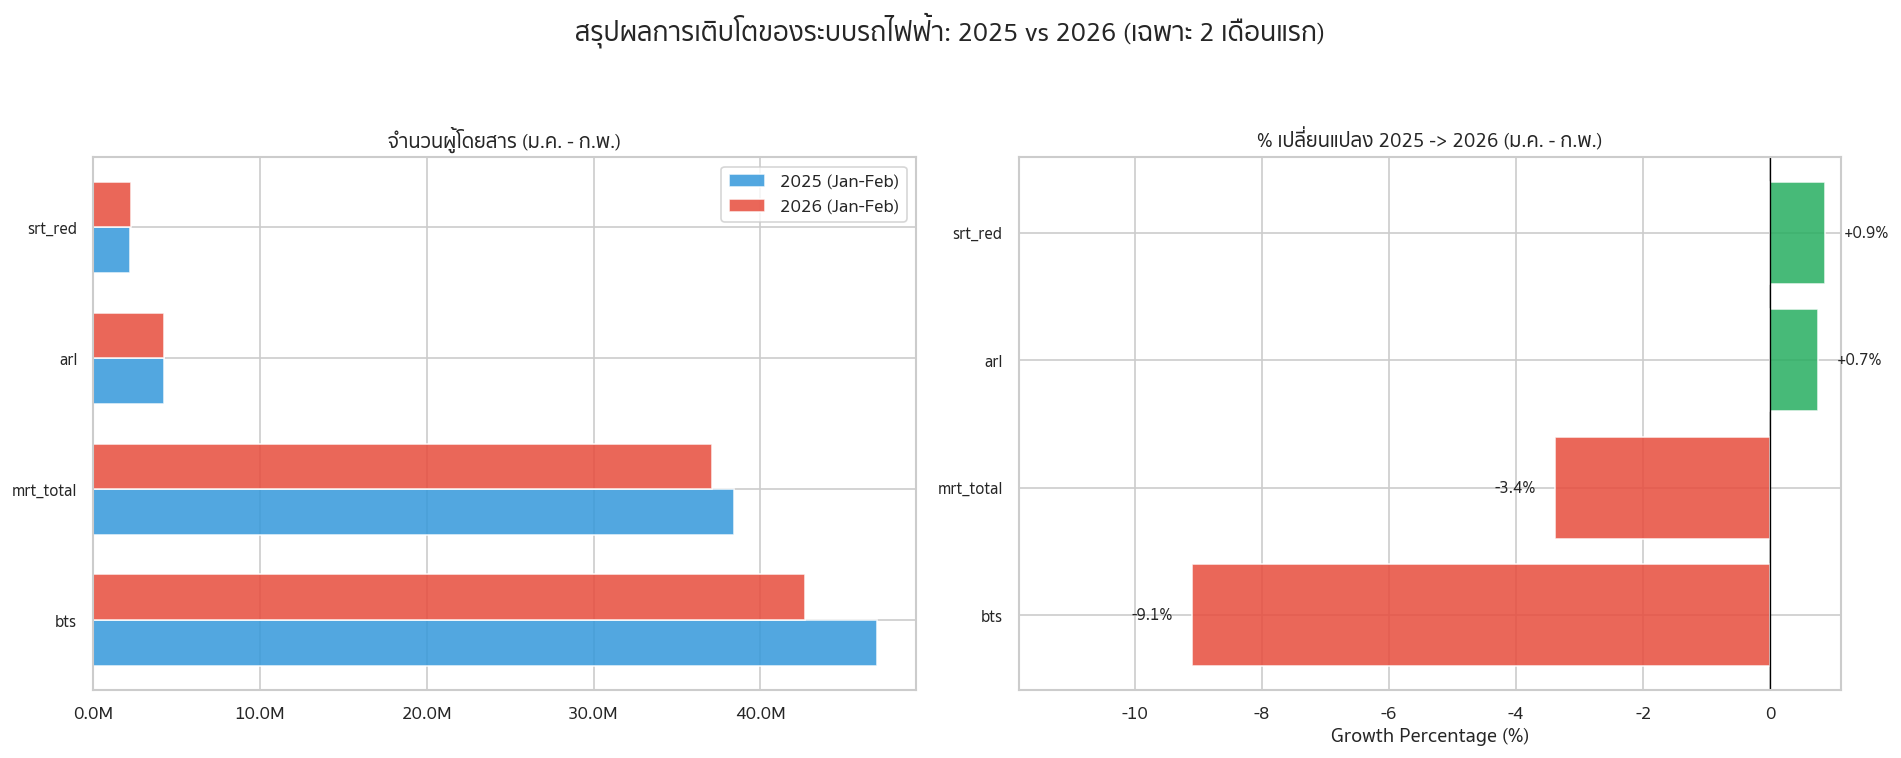

In [40]:
# 1. กรองข้อมูลเฉพาะเดือน ม.ค. - ก.พ. และปีที่ต้องการ
df_filtered = df_first[df_first['date'].dt.month.isin([1, 2])].copy()
df_filtered['Year'] = df_filtered['date'].dt.year

# 2. จัดกลุ่มข้อมูล (Groupby) ตามปี และรวมสายรถไฟฟ้า
# (หากคุณยังไม่ได้รวม MRT สามารถใช้คำสั่ง df_rail['mrt_total'] = ... ก่อนหน้านี้ได้ครับ)
by_line = df_filtered.groupby('Year')[['arl', 'bts', 'srt_red', 'mrt_total']].sum().T

# 3. คำนวณ % Change
by_line['change_pct'] = ((by_line[2026] - by_line[2025]) / by_line[2025]) * 100
by_line = by_line.sort_values('change_pct', ascending=True)

# 4. สร้างกราฟ 2 ฝั่ง (Subplots)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(by_line))
w = 0.35

# กราฟด้านซ้าย: จำนวนผู้โดยสารรวม (Bar Chart)
axes[0].barh(x - w/2, by_line[2025], w, label='2025 (Jan-Feb)', color='#3498db', alpha=0.85)
axes[0].barh(x + w/2, by_line[2026], w, label='2026 (Jan-Feb)', color='#e74c3c', alpha=0.85)
axes[0].set_yticks(x)
axes[0].set_yticklabels(by_line.index, fontsize=10)
axes[0].set_title('จำนวนผู้โดยสาร (ม.ค. - ก.พ.)', fontweight='bold')
axes[0].legend()
# ปรับตัวเลขแกน X ให้ดูง่าย (หารด้วย 1 ล้าน และเติม M หรือใช้ 1k แล้วแต่ปริมาณข้อมูล)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# กราฟด้านขวา: % Change
colors = ['#27ae60' if v >= 0 else '#e74c3c' for v in by_line['change_pct']]
axes[1].barh(x, by_line['change_pct'], color=colors, alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_yticks(x)
axes[1].set_yticklabels(by_line.index, fontsize=10)
axes[1].set_title('% เปลี่ยนแปลง 2025 -> 2026 (ม.ค. - ก.พ.)', fontweight='bold')
axes[1].set_xlabel('Growth Percentage (%)')

min_val = by_line['change_pct'].min()
max_val = by_line['change_pct'].max()
axes[1].set_xlim(min_val * 1.3, max_val * 1.3)

# ใส่ตัวเลข % กำกับที่ปลายแท่ง
for i, v in enumerate(by_line['change_pct']):
    offset = 0.3 if v >= 0 else -0.3
    align = 'left' if v >= 0 else 'right'
    axes[1].text(v + offset, i, f'{v:+.1f}%', 
                va='center', ha='left' if v >= 0 else 'right', 
                fontsize=10, fontweight='bold')

plt.suptitle('สรุปผลการเติบโตของระบบรถไฟฟ้า: 2025 vs 2026 (เฉพาะ 2 เดือนแรก)', 
             fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

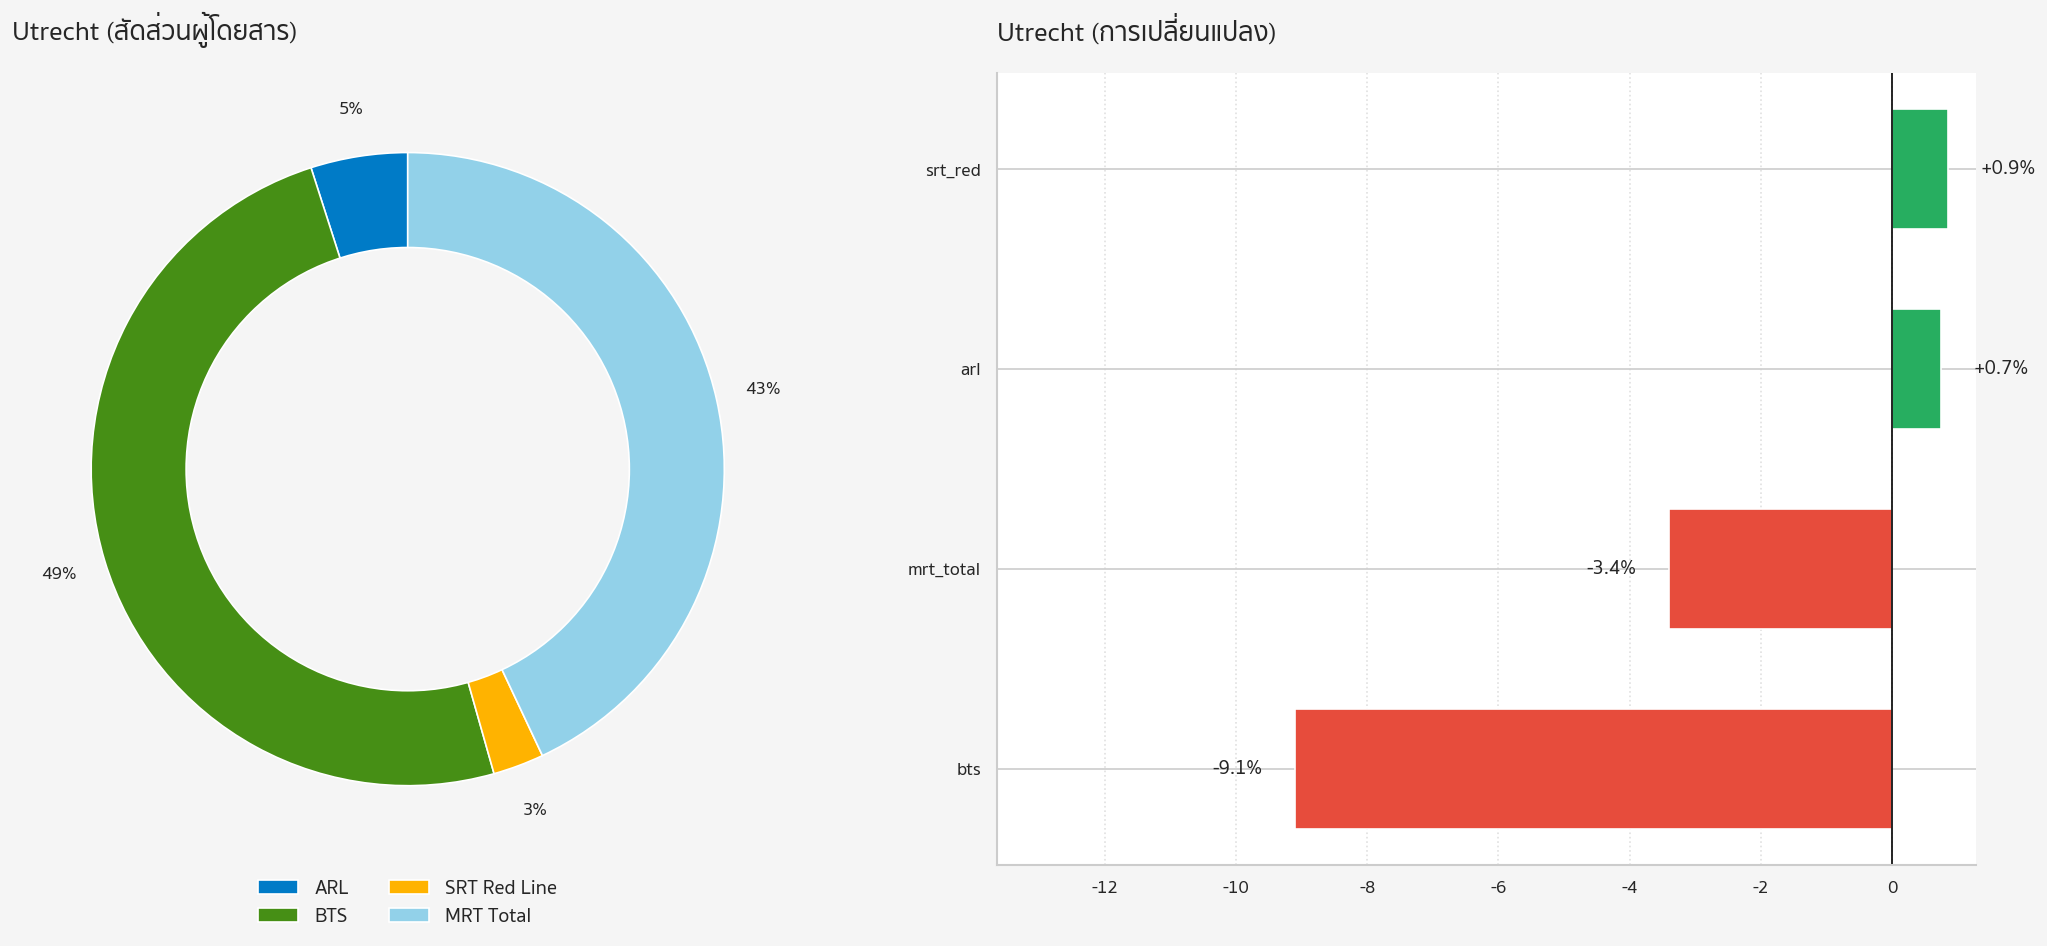

In [43]:
# 1. เตรียมข้อมูลสัดส่วนปี 2026 (ม.ค. - ก.พ.)
data_2026 = by_line[2026]
labels = ['ARL', 'BTS', 'SRT Red Line', 'MRT Total']
# ใช้โทนสีเดียวกับรูปตัวอย่าง (Blue, Green, Orange, Light Blue)
colors_donut = ['#007bc7', '#468f15', '#ffb300', '#92d1e9']

# 2. สร้าง Figure และ Subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 8), facecolor='#f5f5f5') # พื้นหลังเทาอ่อนตามรูป

# --- กราฟซ้าย: Donut Chart (สัดส่วน) ---
# วาด Pie Chart โดยไม่ใส่ Label ข้างใน แต่ใช้เส้นชี้ข้างนอก
wedges, texts, autotexts = axes[0].pie(
    data_2026, 
    autopct='%1.0f%%', 
    startangle=90, 
    colors=colors_donut,
    pctdistance=1.15, # ผลักตัวเลข % ออกไปข้างนอก
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)

# สร้างวงกลมตรงกลาง (Donut hole)
centre_circle = plt.Circle((0,0), 0.70, fc='#f5f5f5') # สีเดียวกับพื้นหลัง
axes[0].add_artist(centre_circle)

# ตั้งชื่อกราฟด้านซ้าย
axes[0].set_title('Utrecht (สัดส่วนผู้โดยสาร)', loc='left', fontsize=16, fontweight='bold', pad=20)

# สร้าง Legend ด้านล่างแบบแนวนอน (Horizontal)
axes[0].legend(wedges, labels, loc="lower center", bbox_to_anchor=(0.5, -0.1),
              ncol=2, frameon=False, fontsize=12)

# --- กราฟขวา: % Change (แท่งแนวนอน) ---
by_line_sorted = by_line.sort_values('change_pct', ascending=True)
y_pos = np.arange(len(by_line_sorted))
growth_colors = ['#27ae60' if v >= 0 else '#e74c3c' for v in by_line_sorted['change_pct']]

axes[1].barh(y_pos, by_line_sorted['change_pct'], color=growth_colors, height=0.6)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(by_line_sorted.index, fontsize=11)
axes[1].set_title('Utrecht (การเปลี่ยนแปลง)', loc='left', fontsize=16, fontweight='bold', pad=20)

# ปรับขอบเขตแกน X และเอาเส้นกรอบออกบางส่วนให้เหมือนรูป
axes[1].set_xlim(min(by_line_sorted['change_pct'])*1.5, max(by_line_sorted['change_pct'])*1.5)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(axis='x', linestyle=':', alpha=0.6)

# ใส่ตัวเลข % กำกับปลายแท่ง
for i, v in enumerate(by_line_sorted['change_pct']):
    offset = 0.5 if v >= 0 else -0.5
    align = 'left' if v >= 0 else 'right'
    axes[1].text(v + offset, i, f'{v:+.1f}%', va='center', ha=align, fontweight='bold')

plt.tight_layout()
plt.show()

สัดส่วนการใช้ระบบขนส่งแต่ละประเภทเป็นอย่างไร

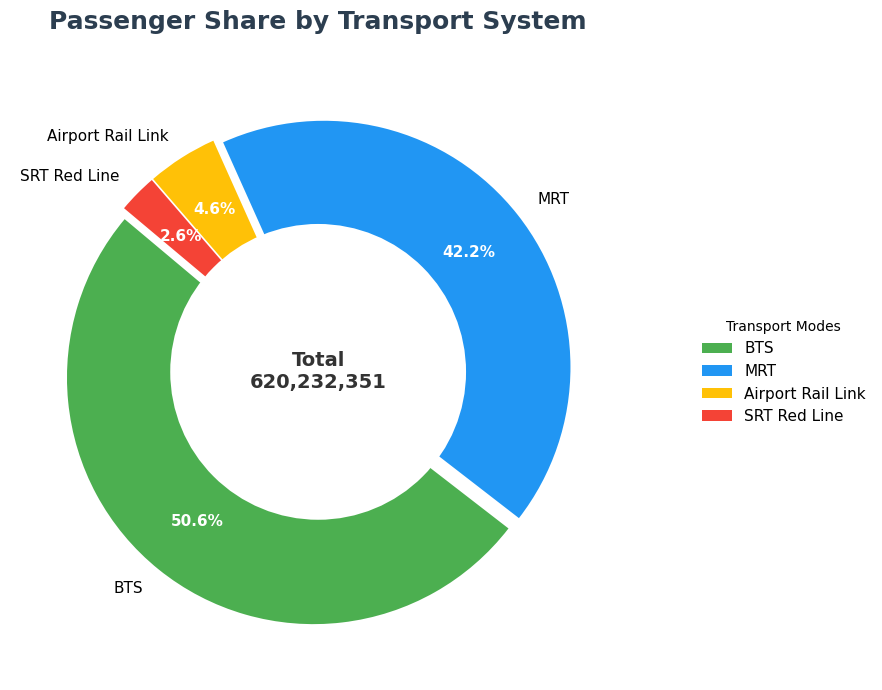

In [12]:
import matplotlib.pyplot as plt

# --- 1. เตรียมข้อมูล ---
# อ้างอิงจากข้อมูลของคุณ
total_by_mode = yearly_summary.sum()
data = total_by_mode.values
labels = total_by_mode.index
# ใช้โทนสีที่นุ่มนวลขึ้นแต่ยังคงเอกลักษณ์เดิม
colors = ['#4CAF50', '#2196F3', '#FFC107', '#F44336'] 

# --- 2. สร้าง Donut Chart ---
fig, ax = plt.subplots(figsize=(10, 7), subplot_kw=dict(aspect="equal"))

# สร้างชิ้นเค้ก
wedges, texts, autotexts = ax.pie(
    data, 
    labels=labels, 
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    pctdistance=0.75,       # ขยับตัวเลข % เข้ามาในชิ้นเค้กเล็กน้อย
    explode=[0.03] * len(data), # ระยะห่างระหว่างชิ้นที่พอดี
    textprops={'fontsize': 11, 'fontweight': '500'}
)

# --- 3. เจาะรูตรงกลาง (The Donut Part) ---
centre_circle = plt.Circle((0,0), 0.60, fc='white')
fig.gca().add_artist(centre_circle)

# ปรับแต่งตัวเลขเปอร์เซ็นต์ในชิ้นเค้ก
plt.setp(autotexts, size=11, color="white", fontweight="bold")

# --- 4. ตกแต่งรายละเอียดให้ Professional ---
# ย้าย Label ออกไปอยู่นอกกราฟด้วยการใช้ Legend ที่จัดวางอย่างสมดุล
ax.legend(
    wedges, labels,
    title="Transport Modes",
    loc="center left",
    bbox_to_anchor=(1.1, 0, 0.5, 1),
    frameon=False,        # เอาขอบสี่เหลี่ยมรอบ Legend ออก
    fontsize=11
)

# เพิ่มคำอธิบายตรงกลาง Donut (Optional - ใส่ยอดรวมได้)
total_sum = data.sum()
ax.text(0, 0, f'Total\n{total_sum:,.0f}', ha='center', va='center', 
        fontsize=14, fontweight='bold', color='#333333')

ax.set_title('Passenger Share by Transport System', 
             fontsize=18, fontweight='bold', pad=25, color='#2c3e50')

plt.tight_layout()
plt.show()

รูปแบบใดที่ เติบโตหรือหดตัวมากที่สุด เมื่อเปรียบเทียบปี 2568 กับ 2569

In [13]:
df_growth = df_first.copy()
df_growth['month'] = df_growth['date'].dt.month

df_growth = df_growth[df_growth['month'].isin([1, 2])]

In [14]:
def get_growth_data(df, target_months=[1, 2]):
    df['date'] = pd.to_datetime(df['date'])
    rail_cols = ['arl', 'bts', 'mrt', 'srt_red']
    
    monthly = (df[df['date'].dt.month.isin(target_months)]
               .groupby(['year', 'month'])[rail_cols]
               .mean())
    
    growth = (monthly.loc[2026] / monthly.loc[2025] - 1) * 100
    
    month_map = {1: 'January', 2: 'February'}
    return growth.rename(index=month_map).dropna()

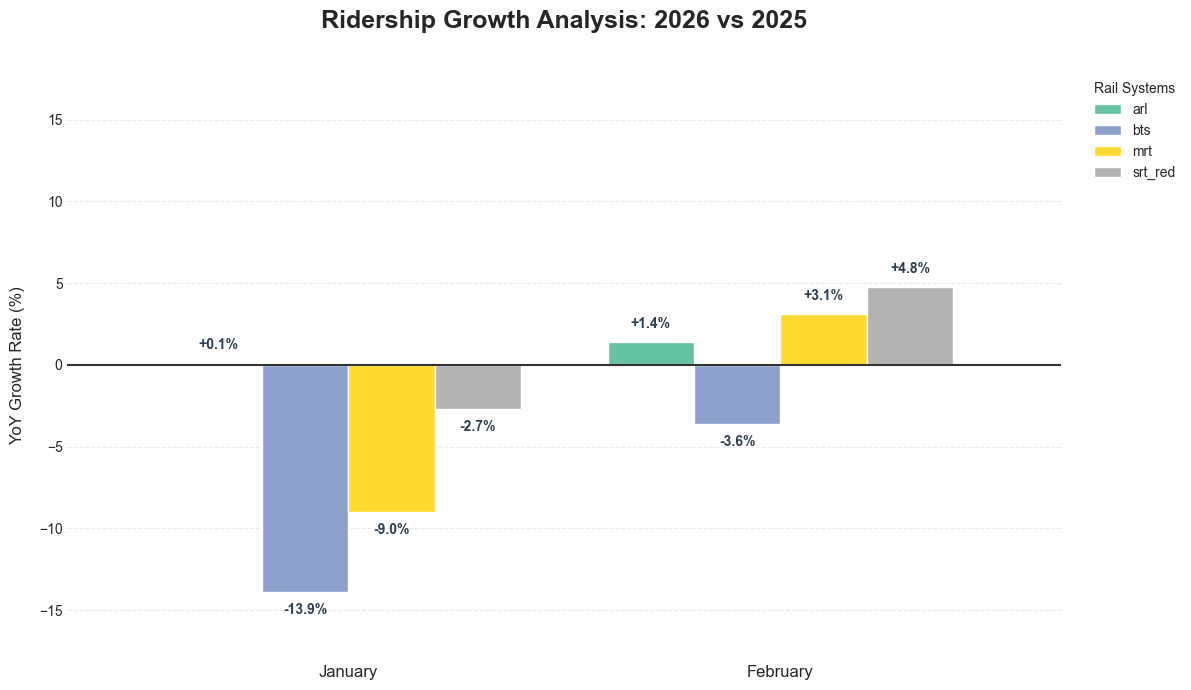

In [15]:
growth_rate = get_growth_data(df_growth)

plt.style.use('seaborn-v0_8-white')
fig, ax = plt.subplots(figsize=(12, 7))

# Plot with a distinct, clean palette
growth_rate.plot(kind='bar', ax=ax, width=0.8, colormap='Set2', edgecolor='white')

# Aesthetics: Remove chart junk
ax.axhline(0, color='#333333', linewidth=1.5) # Strong baseline
ax.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine(left=True, bottom=True) # Remove outer borders

# --- 3. Optimized Data Labels ---
for p in ax.patches:
    val = p.get_height()
    if pd.isna(val) or val == 0: continue
    
    ax.annotate(f'{val:+.1f}%', 
                (p.get_x() + p.get_width() / 2., val),
                ha='center', va='bottom' if val > 0 else 'top',
                xytext=(0, 8 if val > 0 else -8),
                textcoords='offset points',
                fontsize=10, fontweight='600',
                color='#2c3e50')

# --- 4. Labels & Titles ---
ax.set_title('Ridership Growth Analysis: 2026 vs 2025', fontsize=18, pad=30, fontweight='bold')
ax.set_ylabel('YoY Growth Rate (%)', fontsize=12, labelpad=10)
ax.set_xlabel('') # Month names are self-explanatory
ax.tick_params(axis='x', rotation=0, labelsize=12)

plt.legend(title='Rail Systems', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

# Dynamic Y-limit to prevent label clipping
y_max = growth_rate.abs().max().max() * 1.3
ax.set_ylim(-y_max, y_max)

plt.tight_layout()
plt.show()

In [18]:
print(f"{'MONTH':<12} | {'HIGHEST GROWTH':<20} | {'SHARPEST DECLINE'}")
print("-" * 60)
for month, row in growth_rate.iterrows():
    print(f"{month:<12} | {row.idxmax():<10} ({row.max():>6.1f}%) | {row.idxmin():<10} ({row.min():>6.1f}%)")

MONTH        | HIGHEST GROWTH       | SHARPEST DECLINE
------------------------------------------------------------
January      | arl        (   0.1%) | bts        ( -13.9%)
February     | srt_red    (   4.8%) | bts        (  -3.6%)


# โจทย์ 2 : — รถไฟฟ้าในกรุงเทพฯ แต่ละสายมีพฤติกรรมผู้โดยสารต่างกันอย่างไร?

ปริมาณผู้โดยสารของแต่ละสาย

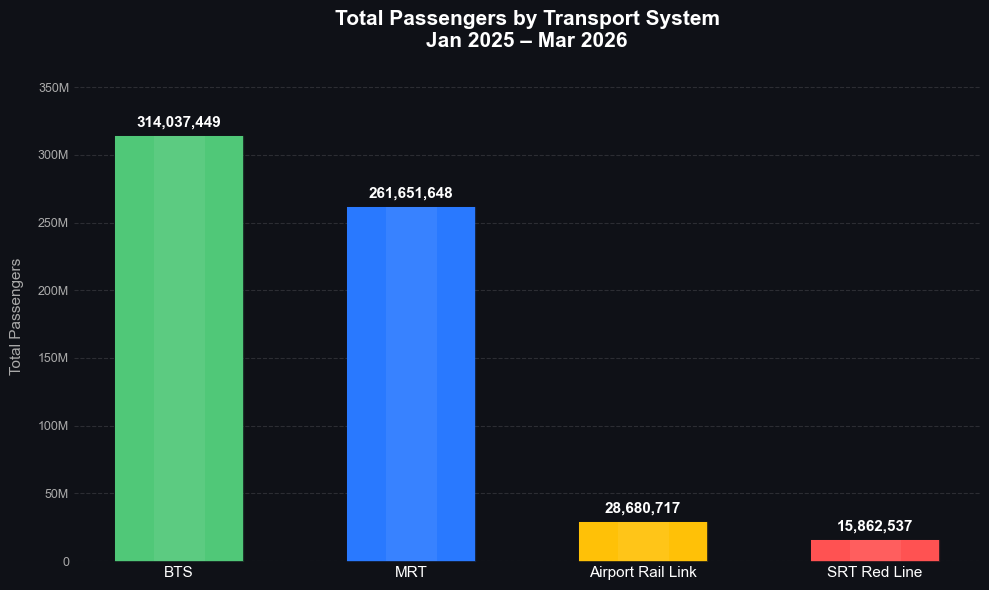

In [16]:
total_by_mode = yearly_summary.sum()
modes = total_by_mode.index
x = np.arange(len(modes))
colors = ['#50c878', '#2979FF', '#FFC107', '#FF5252']

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0F1117')
ax.set_facecolor('#0F1117')

# Bar with rounded top effect using two layers
bars = ax.bar(x, total_by_mode.values, color=colors, width=0.55,
              zorder=3, linewidth=0)

# Gradient-like glow: semi-transparent lighter bar on top
for bar, color in zip(bars, colors):
    ax.bar(bar.get_x() + bar.get_width()/2, bar.get_height(),
           width=bar.get_width() * 0.4, color='white', alpha=0.07, zorder=4)

# Fill under bars (subtle)
for bar, color in zip(bars, colors):
    ax.fill_between(
        [bar.get_x(), bar.get_x() + bar.get_width()],
        [0, 0], [bar.get_height(), bar.get_height()],
        color=color, alpha=0.15, zorder=2
    )

# Bar labels
for bar, color in zip(bars, colors):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + max(total_by_mode.values) * 0.015,
            f'{height:,.0f}',
            ha='center', va='bottom',
            fontsize=11, fontweight='bold', color='white')

# Styling
ax.set_title('Total Passengers by Transport System\nJan 2025 – Mar 2026',
             fontsize=15, fontweight='bold', color='white', pad=18)
ax.set_ylabel('Total Passengers', fontsize=11, color='#AAAAAA', labelpad=10)
ax.set_xticks(x)
ax.set_xticklabels(modes, fontsize=11, color='white')
ax.tick_params(axis='y', colors='#AAAAAA', labelsize=9)
ax.tick_params(axis='x', length=0)

# Y-axis formatter
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1e6:.0f}M' if v >= 1e6 else f'{v:,.0f}'))

# Grid (horizontal only)
ax.yaxis.grid(True, linestyle='--', alpha=0.12, color='white', zorder=0)
ax.set_axisbelow(True)

# Spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Y limit padding
ax.set_ylim(0, max(total_by_mode.values) * 1.15)

plt.tight_layout()
plt.savefig('total_by_mode.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

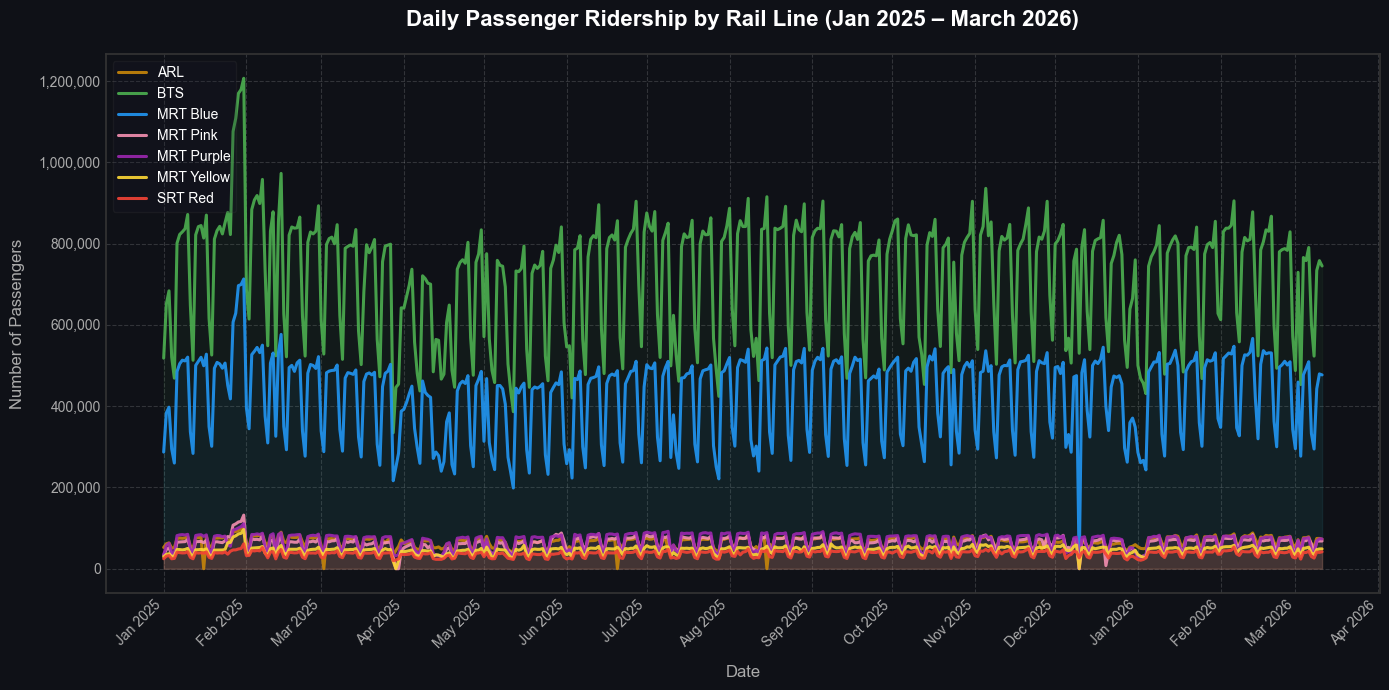

In [22]:
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter

df_trend = df.copy()
df_trend['date'] = pd.to_datetime(df_trend['date'])
df_trend = df_trend.set_index('date')

fig, ax = plt.subplots(figsize=(14, 7))

fig.patch.set_facecolor('#0F1117')
ax.set_facecolor('#0F1117')

colors = ['#C8860A', '#4CAF50', '#2196F3', '#F48FB1', '#9C27B0', '#FDD835', '#F44336']
labels = ['ARL', 'BTS', 'MRT Blue', 'MRT Pink', 'MRT Purple', 'MRT Yellow', 'SRT Red']

for col, color, label in zip(df_trend.columns, colors, labels):
    ax.plot(df_trend.index, df_trend[col],
            linewidth=2.2, color=color, label=label, alpha=0.9)
    ax.fill_between(df_trend.index, df_trend[col], alpha=0.06, color=color)

ax.set_title('Daily Passenger Ridership by Rail Line (Jan 2025 – March 2026)',
             fontsize=16, fontweight='bold', color='white', pad=20)
ax.set_xlabel('Date', fontsize=12, color='#AAAAAA', labelpad=10)
ax.set_ylabel('Number of Passengers', fontsize=12, color='#AAAAAA', labelpad=10)

ax.tick_params(colors='#AAAAAA', labelsize=10)
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')

ax.grid(True, linestyle='--', alpha=0.15, color='white')
ax.set_axisbelow(True)

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.xaxis.set_major_formatter(DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45, ha='right')

legend = ax.legend(
    loc='upper left', frameon=True,
    framealpha=0.2, edgecolor='#444444',
    labelcolor='white', fontsize=10,
    facecolor='#1A1A2E'
)

plt.tight_layout()
plt.savefig('ridership_trend.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

In [23]:
lines = {
    'bts':        'BTS (รวม)',
    'mrt_blue':   'MRT สายสีน้ำเงิน',
    'mrt_pink':   'MRT สายสีชมพู',
    'mrt_purple': 'MRT สายสีม่วง',
    'mrt_yellow': 'MRT สายสีเหลือง',
    'srt_red':    'SRT สายสีแดง',
}

# คำนวณตัวชี้วัดความผันผวน
results = []
for col, name in lines.items():
    s = df[col].dropna()
    cv   = s.std() / s.mean() * 100       # Coefficient of Variation (%)
    mean = s.mean()
    std  = s.std()
    pct_change = s.pct_change().abs().mean() * 100  # mean absolute daily change %
    iqr  = s.quantile(0.75) - s.quantile(0.25)

    results.append({
        'สาย': name, 'col': col,
        'ค่าเฉลี่ย/วัน': mean,
        'SD': std,
        'CV (%)': cv,
        'Daily Chg (%)': pct_change,
        'IQR': iqr,
    })

result_df = pd.DataFrame(results).sort_values('CV (%)', ascending=False)
print(result_df[['สาย', 'ค่าเฉลี่ย/วัน', 'CV (%)', 'Daily Chg (%)', 'IQR']]
      .to_string(index=False, float_format='%.2f'))

             สาย  ค่าเฉลี่ย/วัน  CV (%)  Daily Chg (%)       IQR
   MRT สายสีม่วง       67298.50   29.29            inf  35194.00
   MRT สายสีชมพู       61681.65   26.98            inf  24814.50
MRT สายสีน้ำเงิน      427071.85   23.97            inf 173975.00
 MRT สายสีเหลือง       45446.04   22.18            inf  14000.00
    SRT สายสีแดง       36465.60   20.41          17.76  13090.50
       BTS (รวม)      721925.17   20.29          17.50 237754.00
